# 07. Сравнение моделей и итоговые результаты

**Назначение.** Сопоставить все зафиксированные модели на одной закрытой выборке новых учащихся и отделить качество, калибровку, устойчивость и затраты. Блокнот использует выполненные прогнозы и расчёты предыдущих этапов; модели здесь не обучаются и не выбираются повторно.

Основной итог относится к RoboMission: первый запуск при первом посещении известного задания. Прогноз стохастических моделей усредняет три фиксированных seed; два простых ориентира детерминированы. Школьный cCTt рассматривается как отдельная задача. Во всех таблицах порядок моделей одинаков и определяется LogLoss закрытого теста исключительно для представления результата.

In [1]:
from pathlib import Path
import json
import hashlib


def verify_frozen_training_source(root: Path) -> None:
    """Verify frozen training code before reproducing the recorded evaluation."""
    boundary = root / "dataset/protocol/test_evaluation_boundary.json"
    if not boundary.exists():
        return
    frozen_sources = json.loads(
        (root / "dataset/protocol/frozen_training_sources.json").read_text()
    )
    for filename, expected in frozen_sources["notebooks"].items():
        notebook = json.loads((root / "notebooks" / filename).read_text())
        source = "\n\n".join(
            "".join(cell["source"])
            for cell in notebook["cells"]
            if cell["cell_type"] == "code"
        )
        observed = hashlib.sha256(source.encode()).hexdigest()
        assert (
            observed == expected
        ), "Training source changed after the test was opened."


import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display, Markdown


def resolve_project_root(start: Path) -> Path:
    """Find the repository from its root or any notebook subdirectory."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "dataset/raw").is_dir()
            and (candidate / "requirements.txt").is_file()
        ):
            return candidate
    raise FileNotFoundError(
        "Start Jupyter from the GraphProg repository or its notebooks directory."
    )


ROOT = resolve_project_root(Path.cwd())
for relative in (
    "dataset/processed",
    "dataset/protocol",
    "artifacts/runtime",
    "figures/generated",
):
    (ROOT / relative).mkdir(parents=True, exist_ok=True)


SEED = 20260923
rng = np.random.default_rng(SEED)
font_names = {font.name for font in font_manager.fontManager.ttflist}
assert (
    "Times New Roman" in font_names
), "Install Times New Roman before generating figures."
FONT = "Times New Roman"
FONT_SIZE, TITLE_SIZE, FIGURE_DPI = 18, 20, 350
mpl.rcParams.update(
    {
        "font.family": FONT,
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 18,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 18,
        "figure.dpi": 350,
        "savefig.dpi": 350,
        "axes.unicode_minus": True,
        "mathtext.fontset": "stix",
    }
)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)


def table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Display a complete DataFrame using Jupyter's default table styling."""
    frame.to_csv(ROOT / "artifacts" / f"{name}.csv", index=False)
    with pd.option_context(
        "display.max_rows",
        None,
        "display.max_columns",
        None,
        "display.max_colwidth",
        None,
        "display.width",
        None,
    ):
        display(Markdown(caption))
        display(frame.reset_index(drop=True).round(5))


def save_figure(fig: mpl.figure.Figure, name: str) -> None:
    """Save at 350 dpi after checking the font contract on visible text."""
    from matplotlib.text import Text

    fig.canvas.draw()
    for text in fig.findobj(match=Text):
        if text.get_visible() and text.get_text():
            assert 18 <= text.get_fontsize() <= 20
            assert text.get_fontfamily() == [FONT]
    fig.savefig(
        ROOT / "figures/generated" / f"{name}.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )
    fig.savefig(
        ROOT / "figures/generated" / f"{name}.pdf",
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )


import joblib

verify_frozen_training_source(ROOT)
analysis_path = ROOT / "artifacts/runtime/06_analysis_bundle.joblib"
assert (
    analysis_path.exists()
), "Run 06_Model_Analysis.ipynb successfully before result synthesis."
analysis = joblib.load(analysis_path)
frozen = json.loads(
    (ROOT / "dataset/protocol/frozen_proposed_model.json").read_text()
)
assert (
    analysis["feature_revision"]
    == frozen["feature_revision"]
    == "event_prefix_v2"
)
assert (
    hashlib.sha256(json.dumps(frozen, sort_keys=True).encode()).hexdigest()
    == analysis["frozen_signature"]
)
probabilities = pd.read_pickle(
    ROOT / "artifacts/runtime/06_test_probabilities.pkl"
)
model_order = (
    analysis["primary"].sort_values("LogLoss", kind="stable").Model.tolist()
)
identifiers = ["Model", "Split", "n"]


def result_table(frame: pd.DataFrame, caption: str, name: str) -> None:
    """Keep every model and every declared value in the common model order."""
    assert frame.Model.is_unique
    assert set(frame.Model) == set(model_order)
    selected = frame.set_index("Model").loc[model_order].reset_index()
    assert selected[identifiers].notna().all().all()
    table(selected, caption, name)


## Основное качество

LogLoss оценивает вероятностный прогноз, а 95% интервалы получены bootstrap по учащимся. AUROC и AP вынесены в отдельную таблицу, чтобы сохранить читаемость и не смешивать разные свойства прогноза.

In [2]:
result_table(
    analysis["primary"],
    "Основная метрика: LogLoss ↓ и 95% CI",
    "07_primary_quality",
)


Основная метрика: LogLoss ↓ и 95% CI

,Model,Split,n,LogLoss,CI_low,CI_high
0,GraphTrajectory,Locked test,22899,0.52840,0.52105,0.53610
1,AlphaProg-AGMT,Locked test,22899,0.52915,0.52222,0.53645
2,LightGBM,Locked test,22899,0.53564,0.52894,0.54278
3,TabM,Locked test,22899,0.53631,0.52942,0.54331
4,XGBoost,Locked test,22899,0.53692,0.53033,0.54381
5,DKT,Locked test,22899,0.54160,0.53446,0.54951
6,AKT,Locked test,22899,0.54259,0.53565,0.54979
7,UKT,Locked test,22899,0.54500,0.53834,0.55214
8,RandomForest,Locked test,22899,0.54567,0.53958,0.55230
9,LogisticRegression,Locked test,22899,0.55674,0.54988,0.56407


In [3]:
result_table(
    analysis["ranking"], "Ранжирование: AUROC и AP ↑", "07_ranking_quality"
)


Ранжирование: AUROC и AP ↑

,Model,Split,n,AUROC,AP
0,GraphTrajectory,Locked test,22899,0.80507,0.74117
1,AlphaProg-AGMT,Locked test,22899,0.80469,0.74108
2,LightGBM,Locked test,22899,0.79955,0.73497
3,TabM,Locked test,22899,0.79867,0.73473
4,XGBoost,Locked test,22899,0.79882,0.73472
5,DKT,Locked test,22899,0.79473,0.73131
6,AKT,Locked test,22899,0.79349,0.72697
7,UKT,Locked test,22899,0.79094,0.72334
8,RandomForest,Locked test,22899,0.79373,0.72961
9,LogisticRegression,Locked test,22899,0.78039,0.70667


## Вероятностное качество и калибровка

Низкая средняя ошибка не гарантирует хорошую калибровку в каждой области вероятностей. Brier и ECE дополняются диагностическими intercept и slope; эти диагностические fits не меняли тестовые прогнозы. Для постоянного прогноза GlobalMean совместные intercept и slope неидентифицируемы (NaN); Brier и ECE остаются определены.

In [4]:
result_table(
    analysis["calibration"],
    "Brier и ECE ↓; идеальные intercept = 0 и slope = 1",
    "07_calibration_quality",
)


Brier и ECE ↓; идеальные intercept = 0 и slope = 1

,Model,Split,n,Brier,ECE,Calibration_intercept,Calibration_slope
0,GraphTrajectory,Locked test,22899,0.17795,0.00763,-0.01826,0.97589
1,AlphaProg-AGMT,Locked test,22899,0.17820,0.00865,-0.00120,1.05207
2,LightGBM,Locked test,22899,0.18051,0.01000,-0.00500,1.06820
3,TabM,Locked test,22899,0.18079,0.01173,0.01792,1.07038
4,XGBoost,Locked test,22899,0.18089,0.01459,-0.00731,1.10774
5,DKT,Locked test,22899,0.18265,0.01005,-0.01840,0.95458
6,AKT,Locked test,22899,0.18312,0.00965,0.02896,1.03278
7,UKT,Locked test,22899,0.18430,0.01523,-0.07499,0.99185
8,RandomForest,Locked test,22899,0.18395,0.02851,0.01920,1.24031
9,LogisticRegression,Locked test,22899,0.18832,0.01168,-0.02749,0.98086


## Устойчивость и вес независимого учащегося

Разброс отдельных seeds характеризует оптимизацию. Macro-learner LogLoss придаёт каждому учащемуся одинаковый вес, в отличие от основной средней ошибки по запросам.

In [5]:
result_table(
    analysis["seeds"],
    "Seeds и равный вес учащихся; ошибки ↓",
    "07_robustness_quality",
)


Seeds и равный вес учащихся; ошибки ↓

,Model,Split,n,Runs,Seed_SD,Worst_seed_LogLoss,Macro_learner_LogLoss
0,GraphTrajectory,Locked test,22899,3,0.00025,0.53063,0.56495
1,AlphaProg-AGMT,Locked test,22899,3,0.00035,0.53014,0.56350
2,LightGBM,Locked test,22899,3,0.00016,0.53604,0.56868
3,TabM,Locked test,22899,3,0.00045,0.53780,0.56800
4,XGBoost,Locked test,22899,3,0.00014,0.53723,0.56937
5,DKT,Locked test,22899,3,0.00038,0.54565,0.57950
6,AKT,Locked test,22899,3,0.00176,0.54673,0.57400
7,UKT,Locked test,22899,3,0.00187,0.54969,0.57541
8,RandomForest,Locked test,22899,3,0.00023,0.54602,0.57429
9,LogisticRegression,Locked test,22899,3,0.00000,0.55674,0.60324


## Вычислительная эффективность

Полный fit компонентов и их инференс суммированы для прогнозируемого ансамбля. OOF и поиск настроек исключены из времени fit; для fusion это существенные дополнительные затраты. Stored_MB включает веса, словари и обученные преобразования; входные массивы и производный синтаксический кэш исключены. Пиковая RAM отдельно не измерялась. Времена получены на указанных CPU/MPS устройствах и не являются сравнением архитектур при одинаковом аппаратном исполнении. Прочерки/NaN у простых ориентиров означают отсутствие отдельного измерения, а не нулевые затраты.

In [6]:
result_table(
    analysis["efficiency"],
    "Компонентное время, с, и размер сохранённого состояния, MB",
    "07_efficiency",
)


Компонентное время, с, и размер сохранённого состояния, MB

,Model,Split,n,Device,Full_fit_s,Inference_s,Stored_MB
0,GraphTrajectory,Locked test,22899,MPS,600.29670,6.72683,0.36226
1,AlphaProg-AGMT,Locked test,22899,CPU + MPS,621.38665,8.17085,5.13044
2,LightGBM,Locked test,22899,CPU,10.90925,0.77228,2.38687
3,TabM,Locked test,22899,MPS,70.77011,1.17843,0.24860
4,XGBoost,Locked test,22899,CPU,9.59026,0.21722,1.78999
5,DKT,Locked test,22899,MPS,69.22413,1.17507,0.60754
6,AKT,Locked test,22899,CPU,2044.29936,13.95089,1.90342
7,UKT,Locked test,22899,MPS,2626.09406,4.40544,1.59997
8,RandomForest,Locked test,22899,CPU,20.61853,0.46211,46.30235
9,LogisticRegression,Locked test,22899,CPU,32.48178,0.10824,0.03543


## Статистическая и практическая значимость

Holm-коррекция применяется ко всему объявленному семейству сравнений. Практическая поддержка требует нижней границы 95% CI снижения LogLoss выше 0,005. Ни одно благоприятное значение p само по себе не доказывает превосходства по всем метрикам.

In [7]:
table(
    analysis["statistics"][
        [
            "Model",
            "Comparator",
            "Split",
            "n",
            "p_raw",
            "p_Holm",
            "Practical_support",
        ]
    ],
    "Парные кластерные сравнения и практическая поддержка",
    "07_statistical_tests",
)


Парные кластерные сравнения и практическая поддержка

,Model,Comparator,Split,n,p_raw,p_Holm,Practical_support
0,AlphaProg-AGMT,GlobalMean,Locked test,22899,0.00050,0.00550,True
1,AlphaProg-AGMT,ItemMean,Locked test,22899,0.00050,0.00550,True
2,AlphaProg-AGMT,LogisticRegression,Locked test,22899,0.00050,0.00550,True
3,AlphaProg-AGMT,RandomForest,Locked test,22899,0.00050,0.00550,True
4,AlphaProg-AGMT,XGBoost,Locked test,22899,0.00050,0.00550,True
5,AlphaProg-AGMT,LightGBM,Locked test,22899,0.00050,0.00550,True
6,AlphaProg-AGMT,DKT,Locked test,22899,0.00050,0.00550,True
7,AlphaProg-AGMT,AKT,Locked test,22899,0.00050,0.00550,True
8,AlphaProg-AGMT,UKT,Locked test,22899,0.00050,0.00550,True
9,AlphaProg-AGMT,TabM,Locked test,22899,0.00050,0.00550,True


## Эффекты относительно сильных ориентиров

Forest plot показывает снижение LogLoss относительно лучших ML- и DL-моделей, выбранных до открытия теста, и одиночного структурно-временного эксперта. Положительный эффект соответствует меньшей ошибке AlphaProg-AGMT; вертикальные ориентиры обозначают ноль и практический порог. Интервалы 95% являются точечными. Поправка Holm в таблице относится к тестам нулевого эффекта и не является одновременной поправкой этих интервалов.

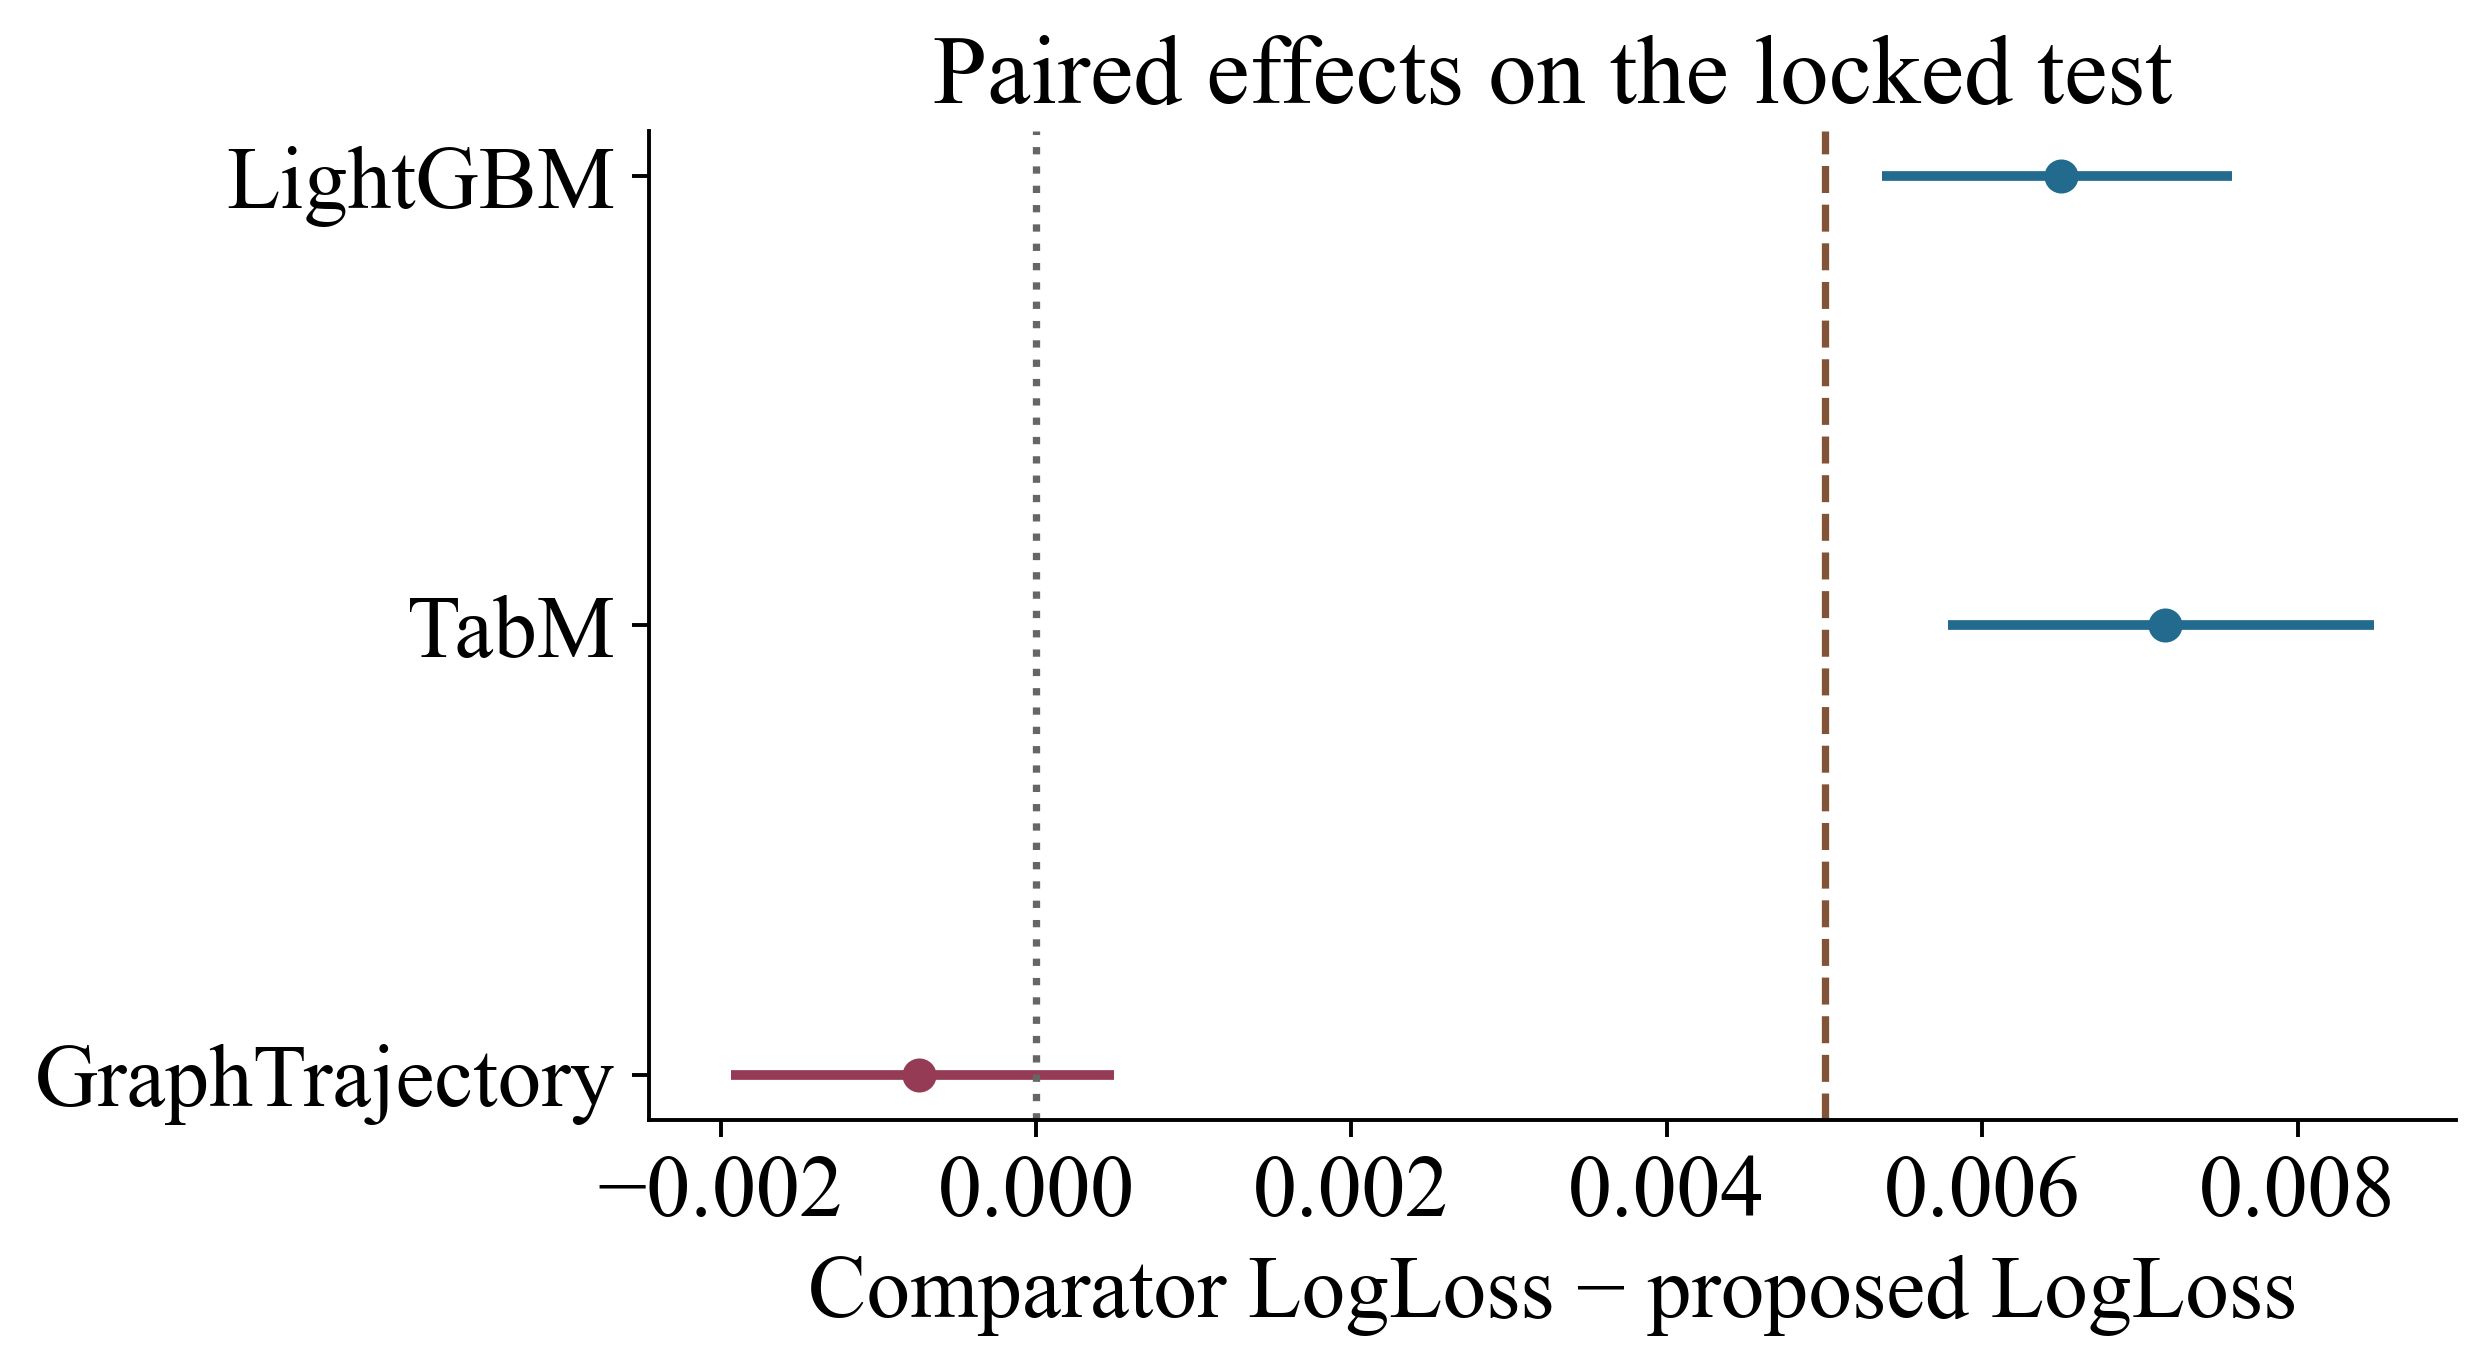

In [8]:
selected_comparators = list(
    dict.fromkeys(analysis["diagnostic_models"][:-1] + ["GraphTrajectory"])
)
effects = (
    analysis["statistics"]
    .set_index("Comparator")
    .loc[selected_comparators]
    .reset_index()
)
fig, ax = plt.subplots(
    figsize=(7.0, max(3.8, 0.65 * len(effects) + 1.8)), layout="constrained"
)
positions = np.arange(len(effects))
for index, row in effects.iterrows():
    color = "#236B8E" if row.CI_low > 0 else "#963B55"
    ax.hlines(index, row.CI_low, row.CI_high, color=color, linewidth=2)
    ax.plot(row.Effect, index, "o", color=color)
ax.axvline(0, color="#666666", linestyle=":")
ax.axvline(
    frozen["practical_logloss_difference"], color="#825337", linestyle="--"
)
ax.set_yticks(positions, effects.Comparator)
ax.invert_yaxis()
ax.set(
    xlabel="Comparator LogLoss − proposed LogLoss",
    title="Paired effects on the locked test",
)
ax.spines[["top", "right"]].set_visible(False)
save_figure(fig, "07_paired_effects")
plt.show()


## Финальная калибровка

Кривая и интервалы показывают структуру отклонений, которая не выражается одним ECE. Все интервалы пересчитываются по целым учащимся на этапе анализа; здесь отображаются эти вычисленные значения.

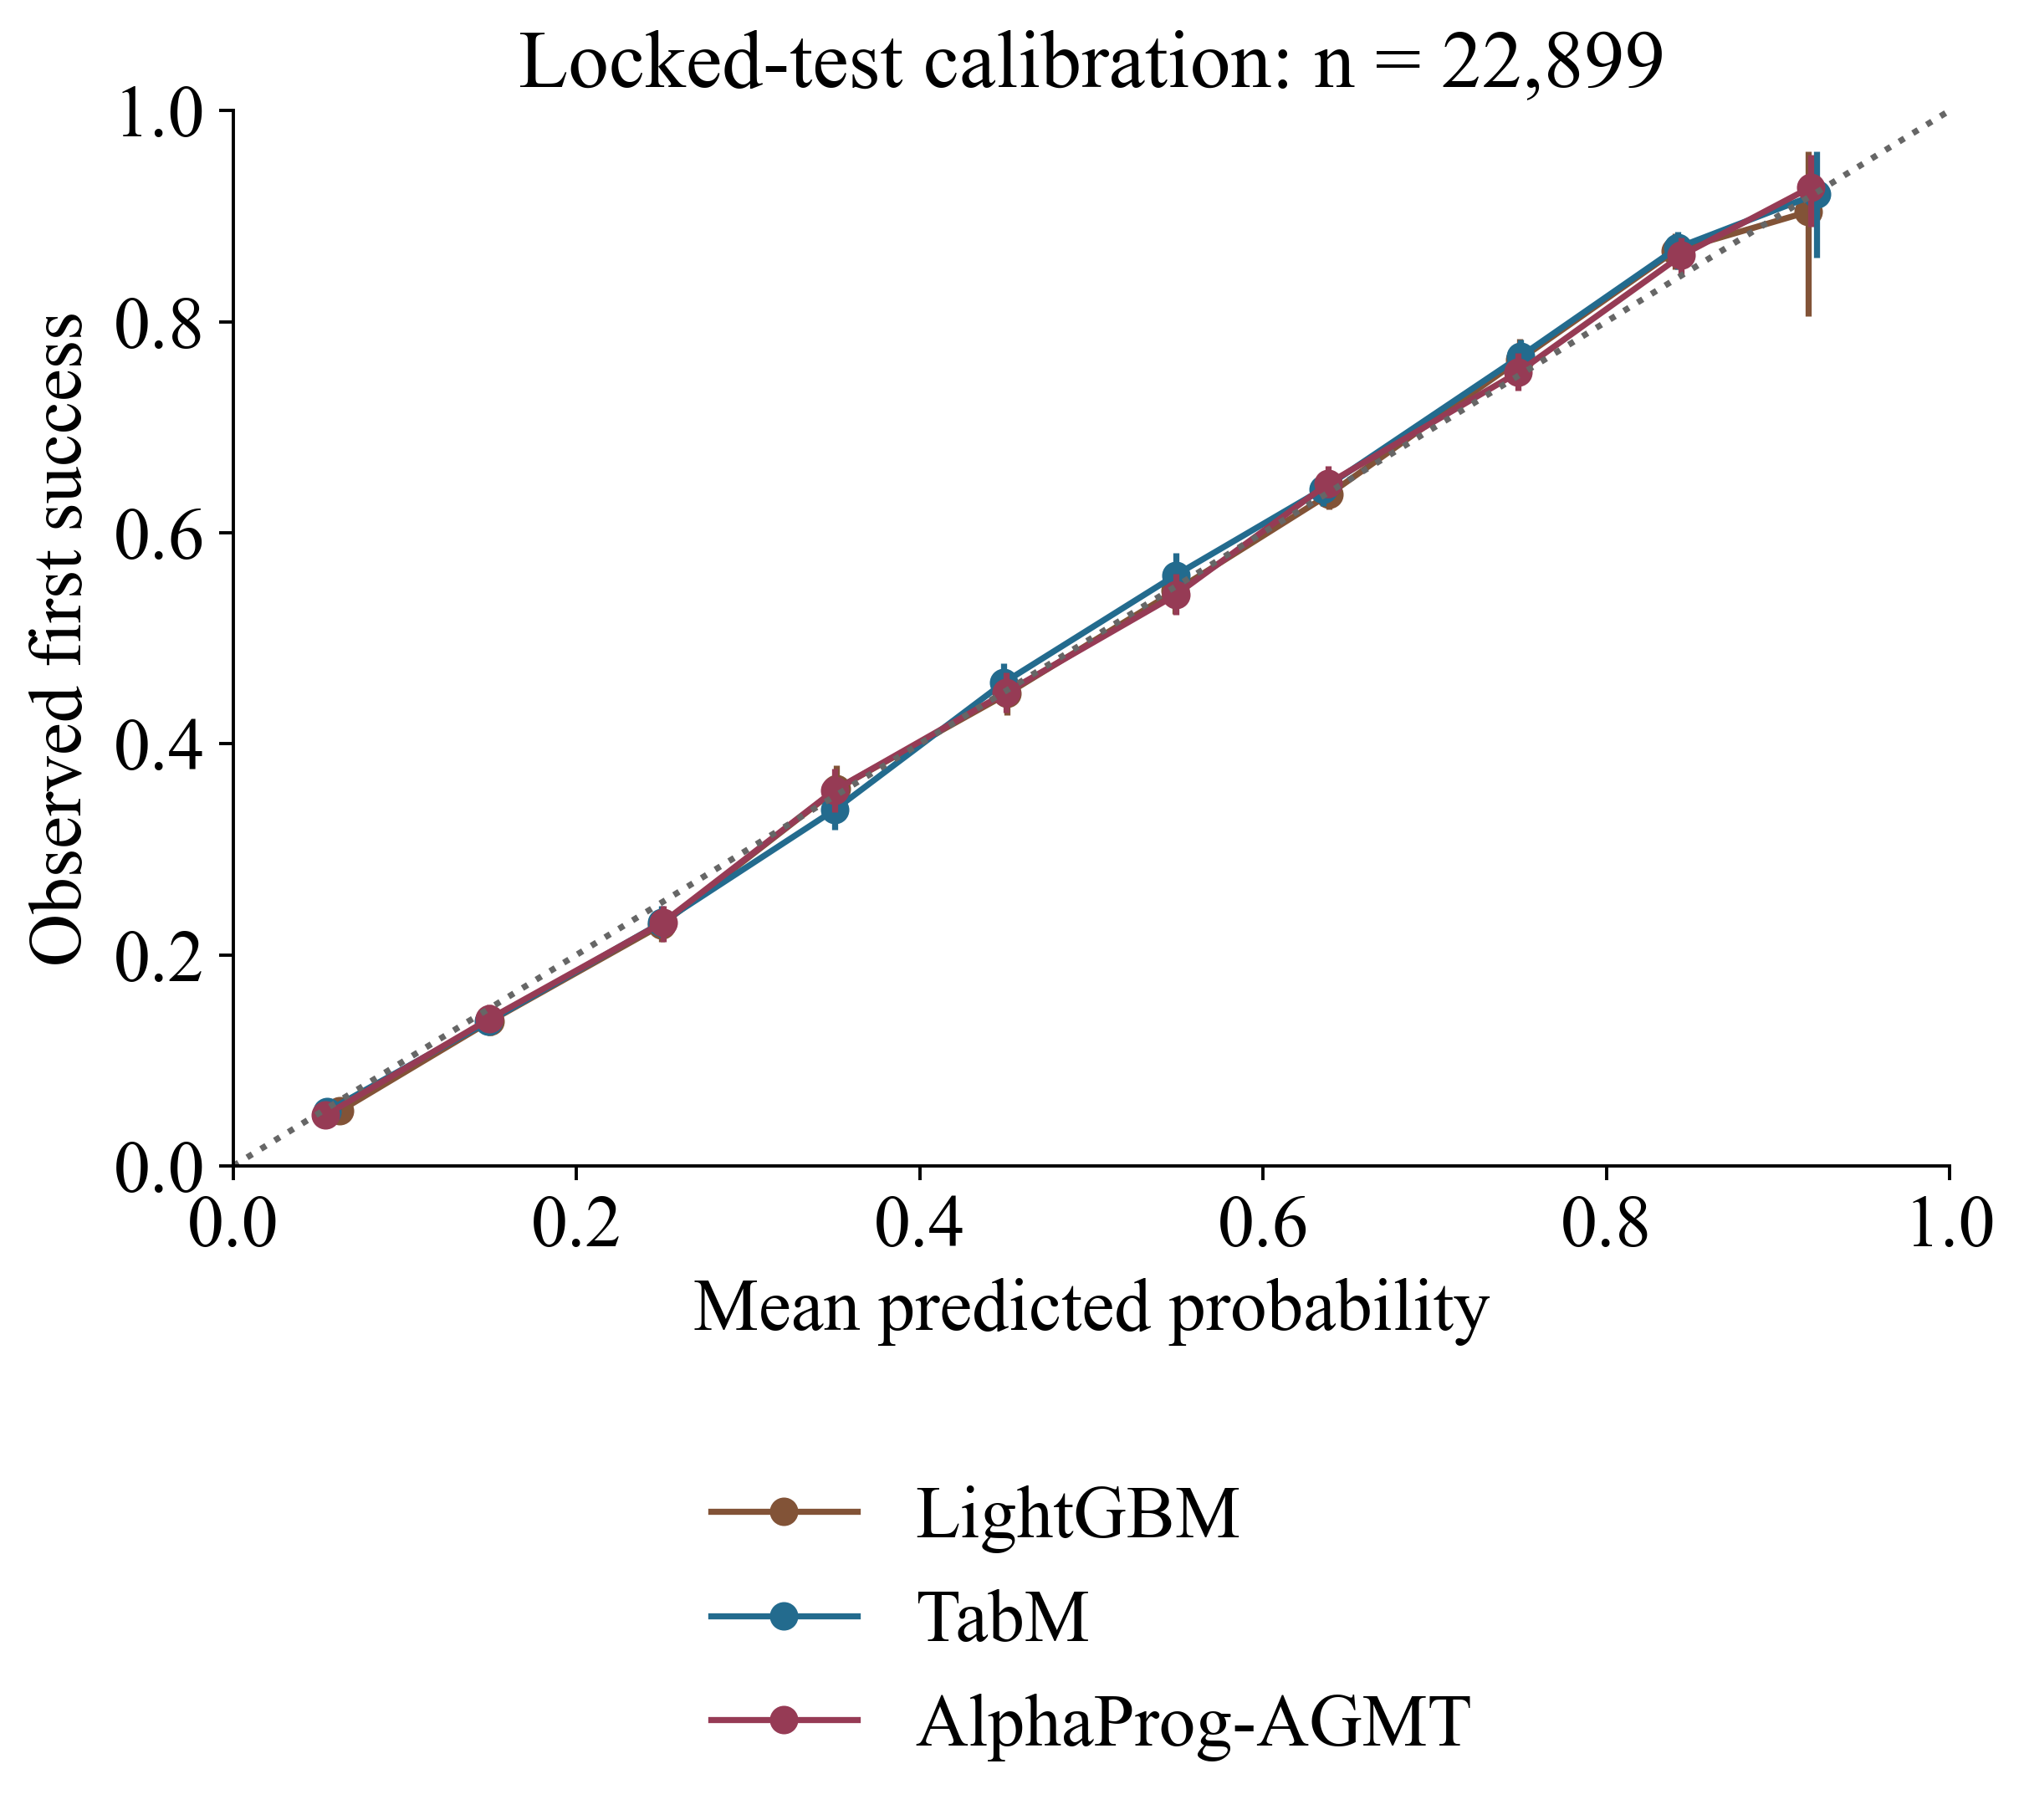

In [9]:
fig, ax = plt.subplots(figsize=(6.8, 6.1), layout="constrained")
for name, color in zip(
    analysis["diagnostic_models"], ["#825337", "#236B8E", "#963B55"]
):
    bins = analysis["calibration_bins"][
        analysis["calibration_bins"].Model.eq(name)
    ]
    if bins.empty:
        continue
    ax.plot(bins.Predicted, bins.Observed, "o-", label=name, color=color)
    ax.vlines(bins.Predicted, bins.CI_low, bins.CI_high, color=color)
ax.plot([0, 1], [0, 1], linestyle=":", color="#666666")
ax.set(
    xlabel="Mean predicted probability",
    ylabel="Observed first success",
    xlim=(0, 1),
    ylim=(0, 1),
    title=f"Locked-test calibration: n = {len(probabilities):,}",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), frameon=False)
save_figure(fig, "07_calibration")
plt.show()


## Финальный анализ устойчивости

Потеря истории проверяет конкретный режим отказа: описание задания доступно, но прошлый журнал недоступен. Это дополнение к вариации seeds, а не доказательство устойчивости к произвольному сдвигу данных.

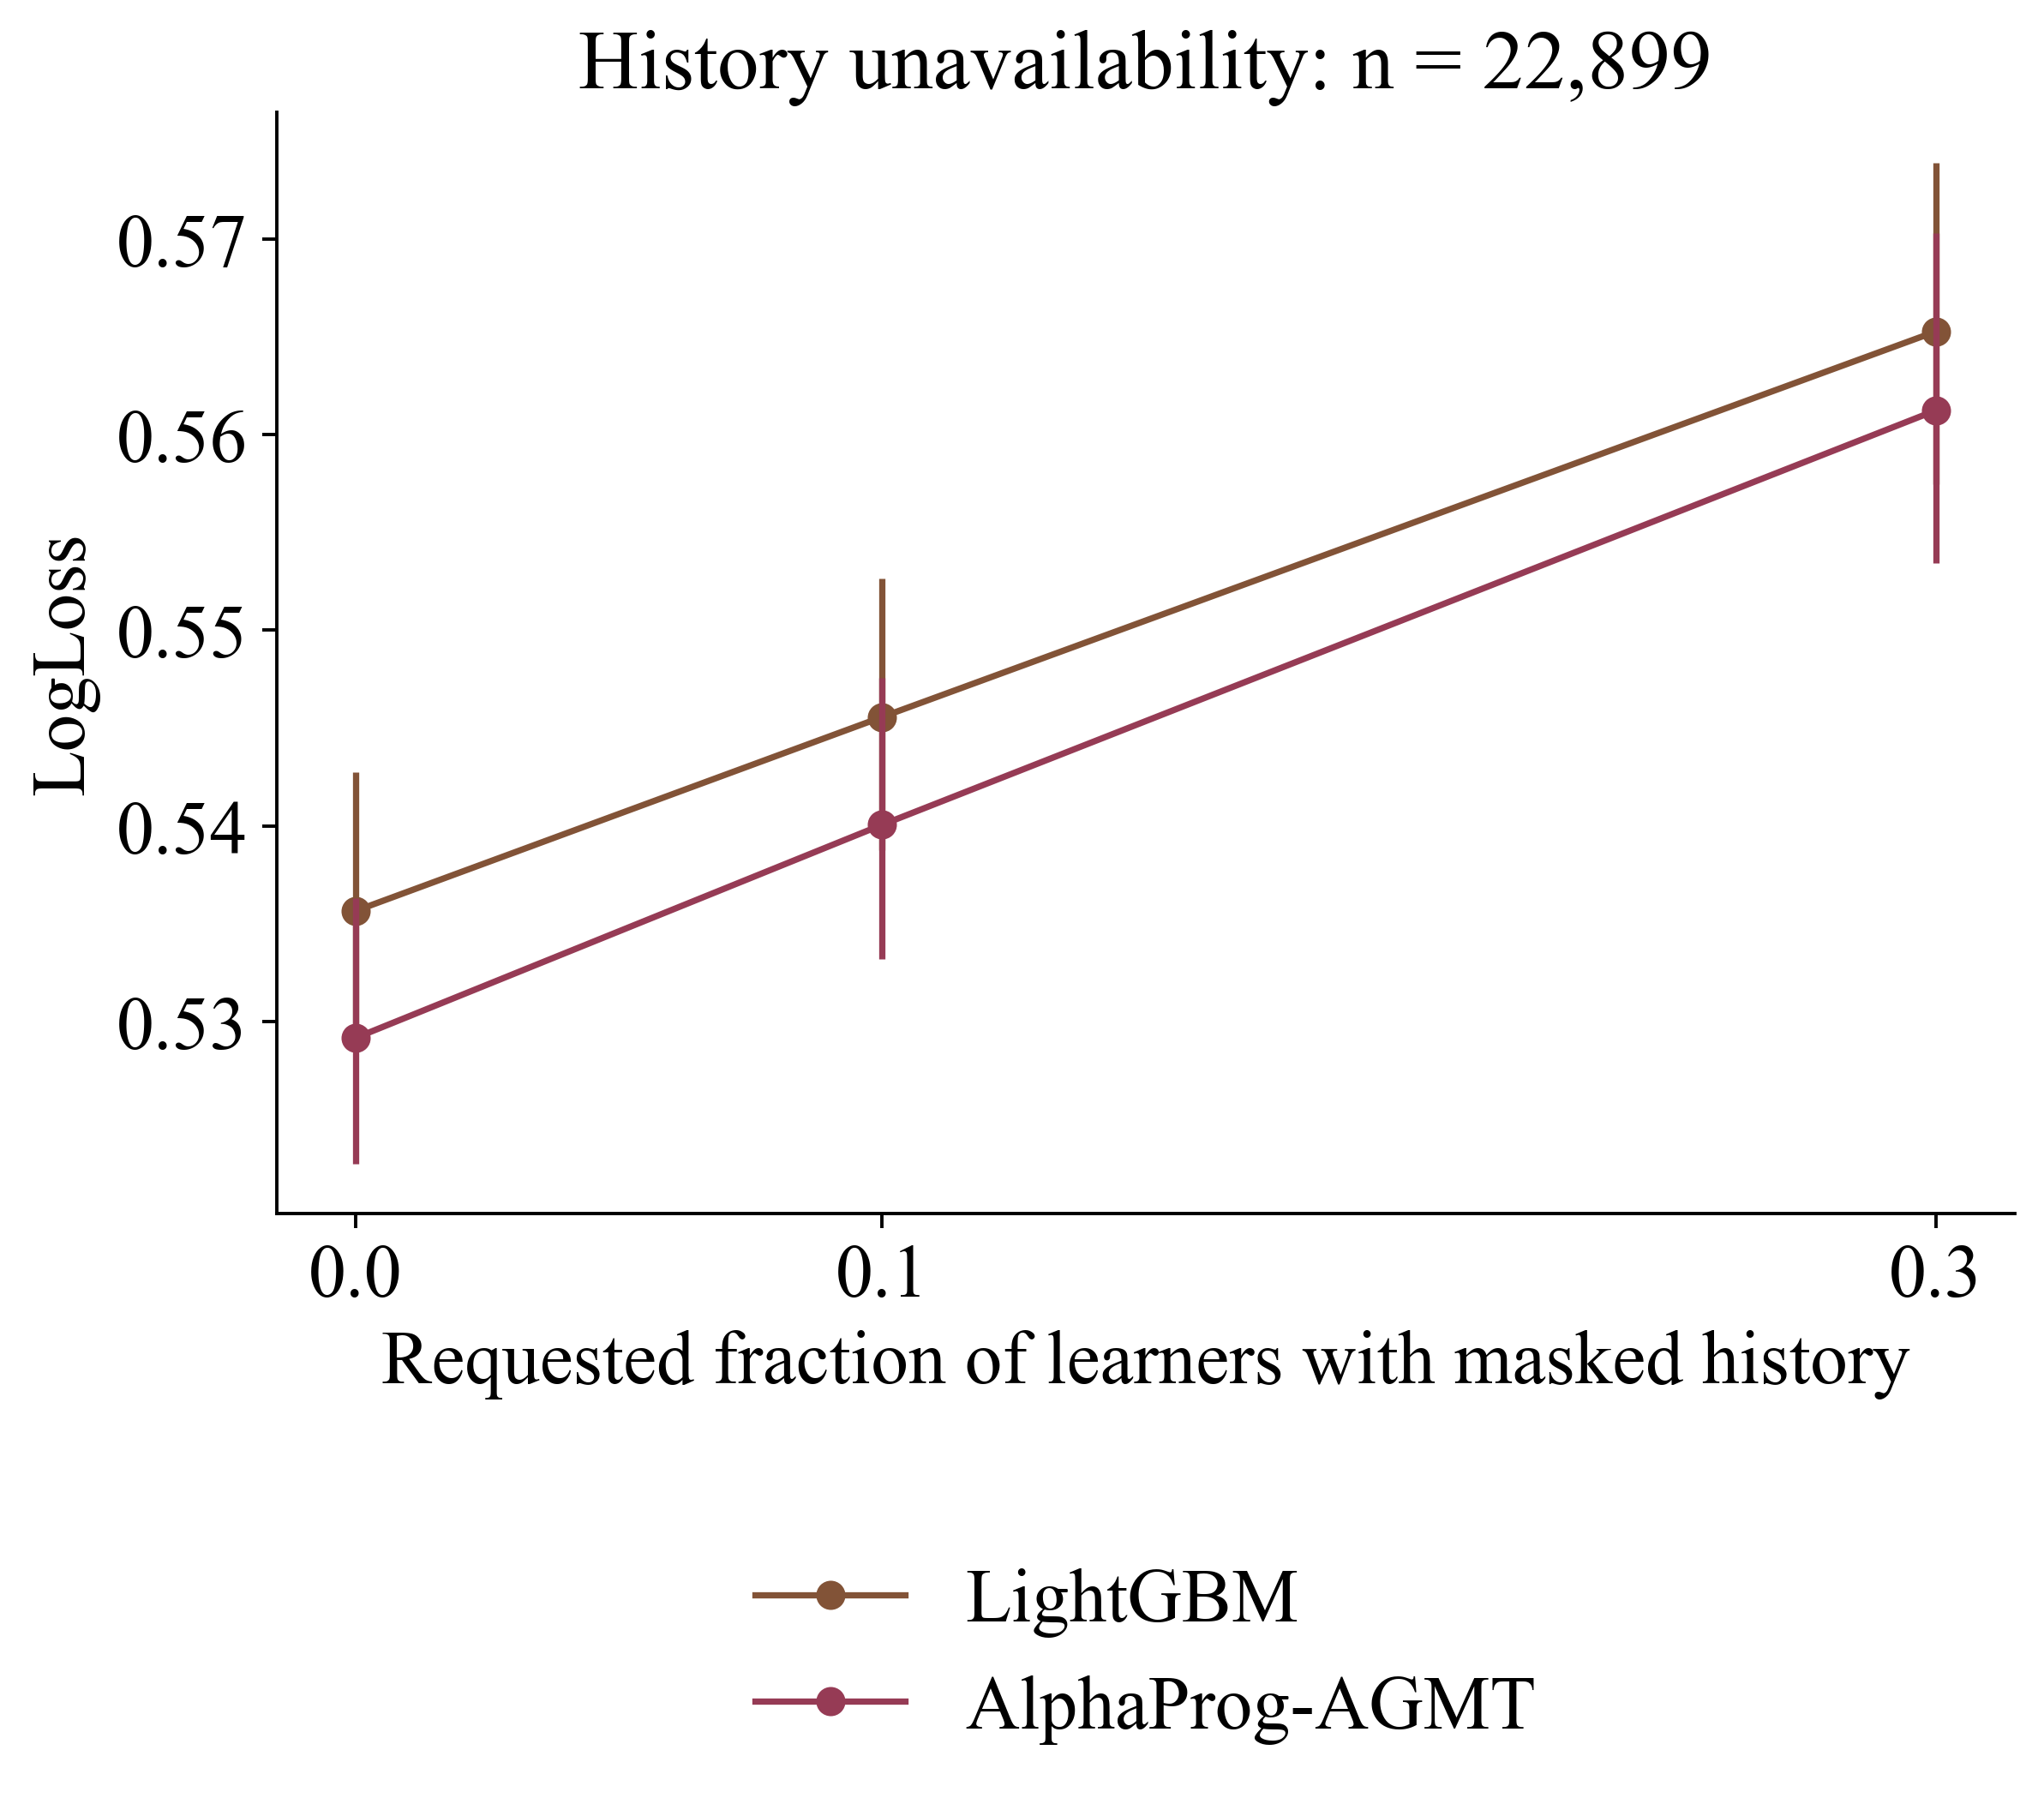

In [10]:
robustness = analysis["robustness"]
fig, ax = plt.subplots(figsize=(6.7, 5.9), layout="constrained")
for (name, group), color in zip(
    robustness.groupby("Model", sort=False), ["#825337", "#963B55"]
):
    ax.plot(group.Mask_fraction, group.LogLoss, "o-", label=name, color=color)
    ax.vlines(group.Mask_fraction, group.CI_low, group.CI_high, color=color)
ax.set_xticks(frozen["robust_history_mask_fractions"])
ax.set(
    xlabel="Requested fraction of learners with masked history",
    ylabel="LogLoss",
    title=f"History unavailability: n = {len(probabilities):,}",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.26), frameon=False)
save_figure(fig, "07_robustness")
plt.show()


## Характер ошибок

Распределение индивидуальной ошибки показывает, сосредоточено ли отличие моделей в типичных запросах или в тяжёлом хвосте. Все наблюдения сохранены, а одинаковые значения объединены в корректную эмпирическую функцию распределения.

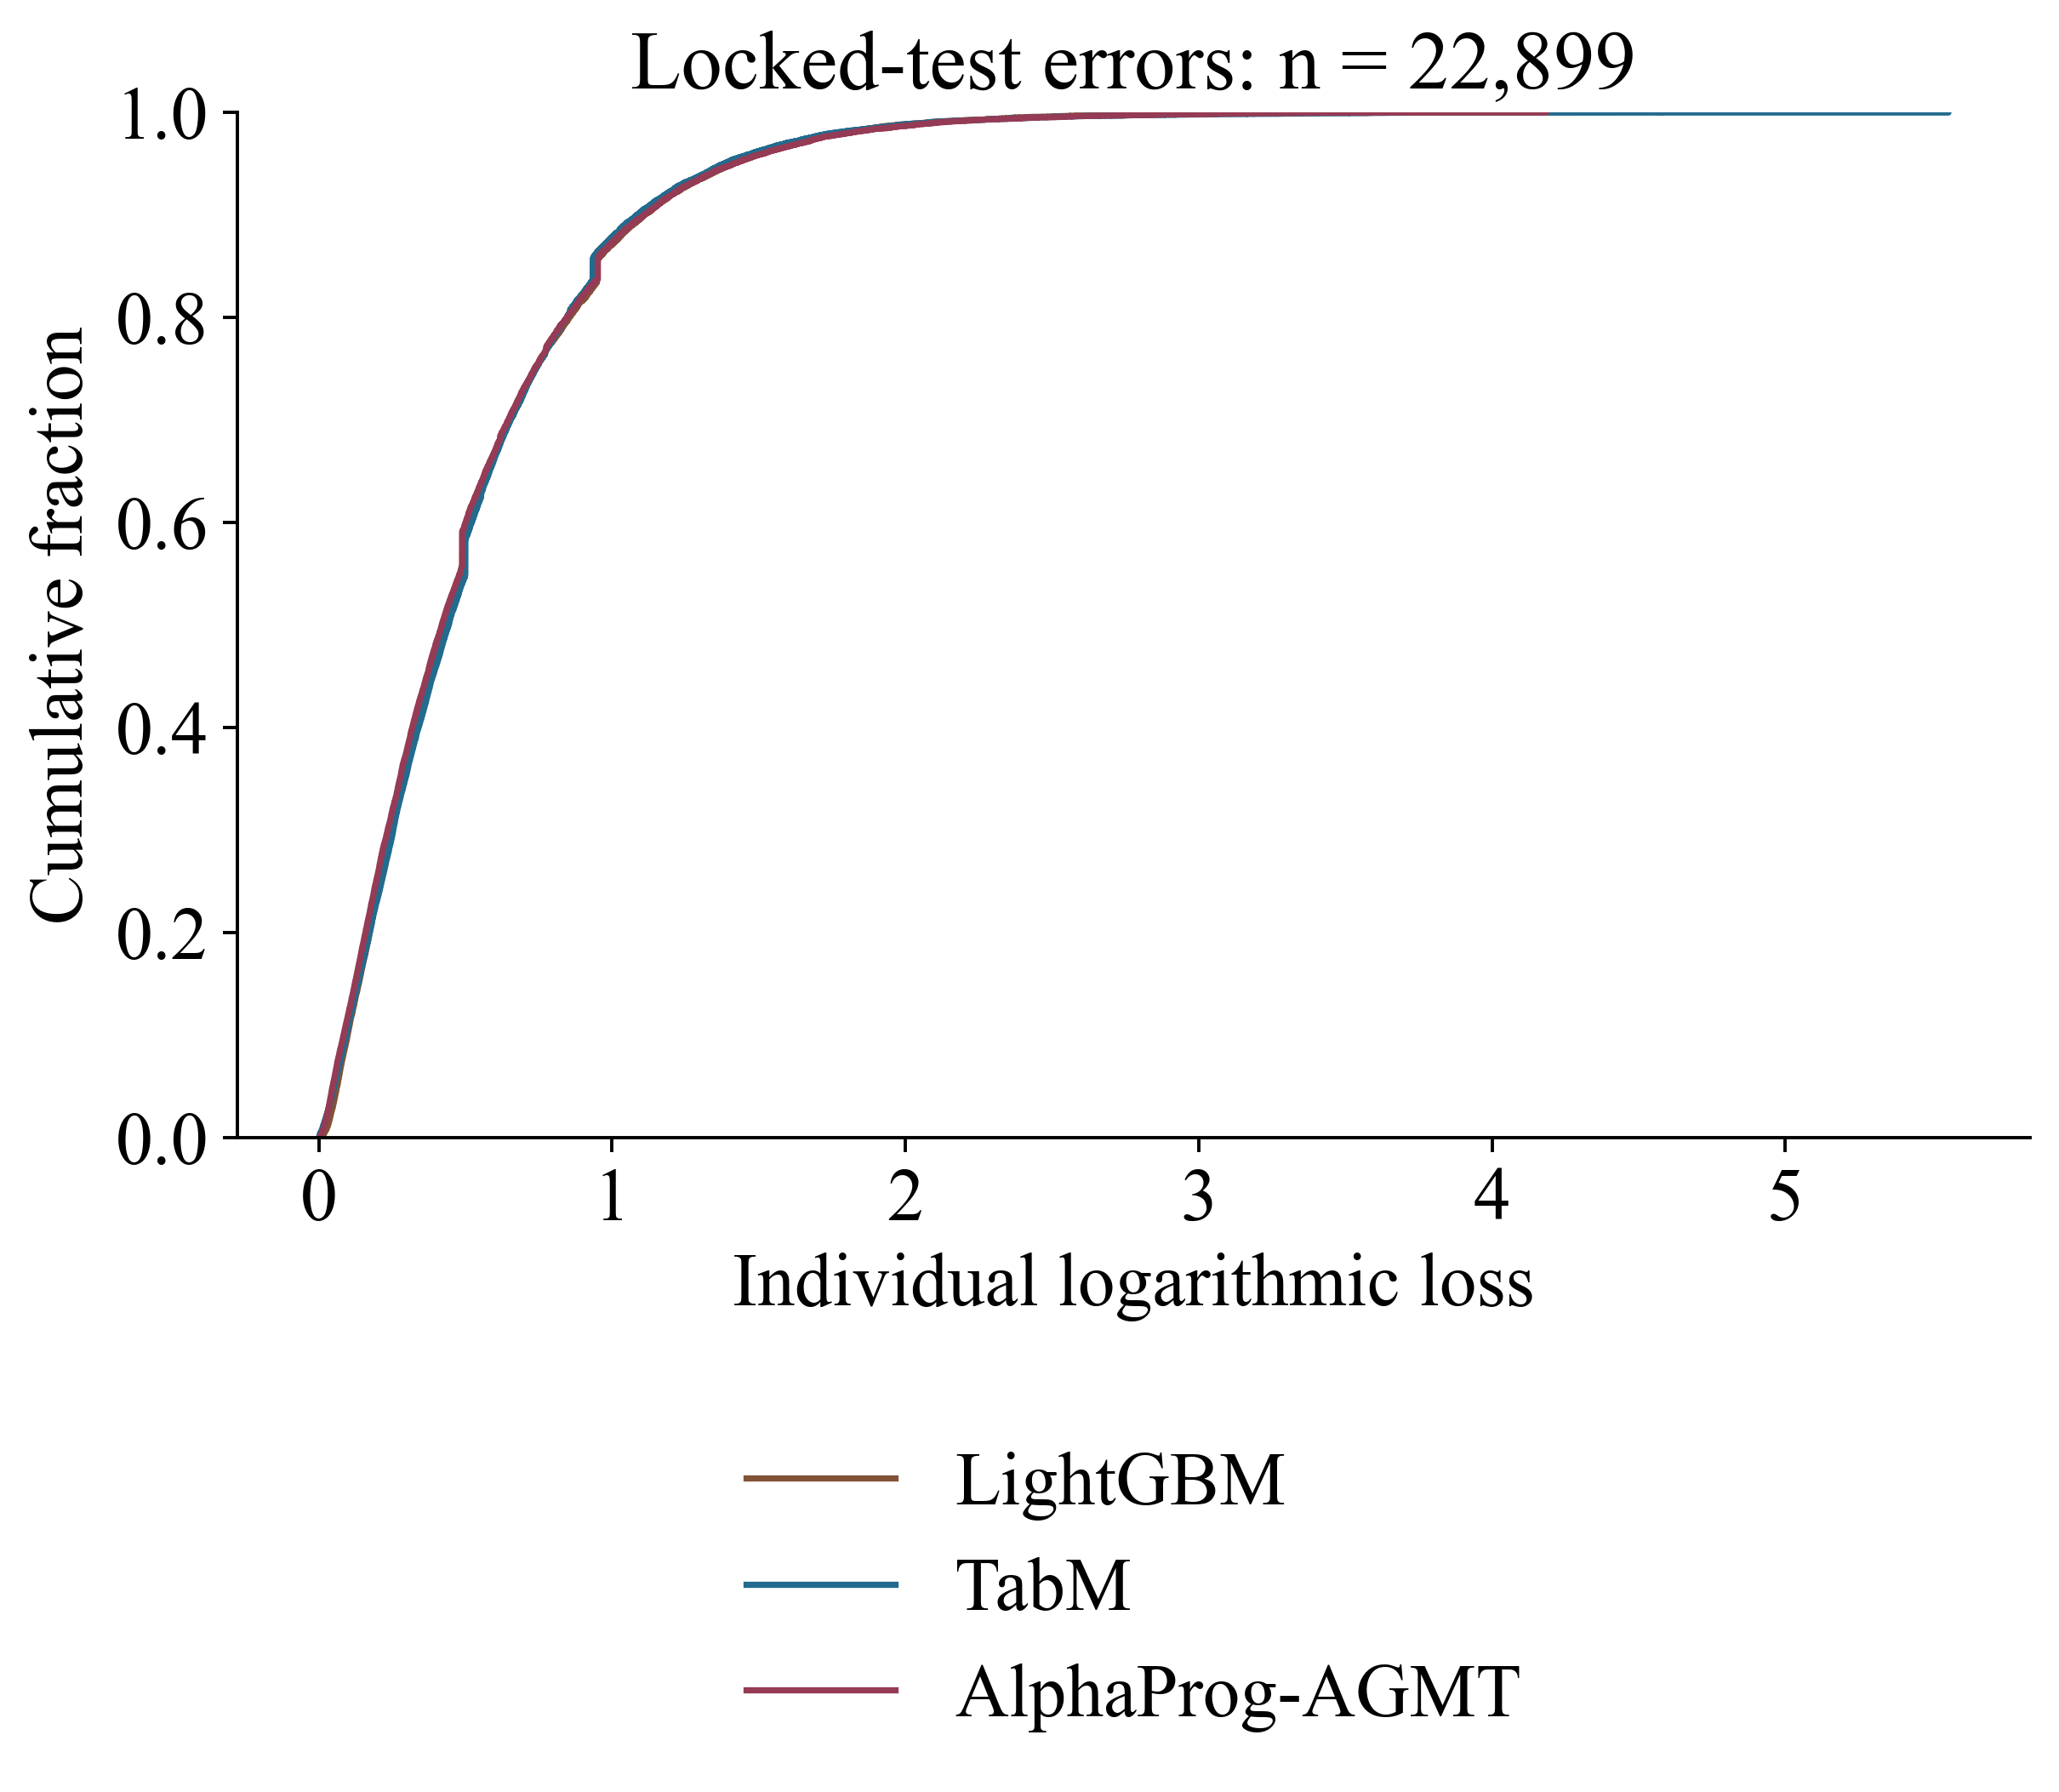

In [11]:
fig, ax = plt.subplots(figsize=(6.8, 5.9), layout="constrained")
truth = probabilities.y.to_numpy()
for name, color in zip(
    analysis["diagnostic_models"], ["#825337", "#236B8E", "#963B55"]
):
    probability = np.clip(probabilities[name].to_numpy(), 1e-6, 1 - 1e-6)
    losses = -(
        truth * np.log(probability) + (1 - truth) * np.log1p(-probability)
    )
    values, counts = np.unique(losses, return_counts=True)
    ax.step(
        values,
        counts.cumsum() / counts.sum(),
        where="post",
        label=name,
        color=color,
    )
ax.set(
    xlabel="Individual logarithmic loss",
    ylabel="Cumulative fraction",
    ylim=(0, 1),
    title=f"Locked-test errors: n = {len(probabilities):,}",
)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.24), frameon=False)
save_figure(fig, "07_errors")
plt.show()


## Проверка компонентов на закрытом тесте

Для абляций сохранён общий seed 17. Эти значения не смешиваются с основным сравнением ансамблей трёх seeds. Таблица позволяет проверить необходимость новых компонентов без изменения конфигурации по тесту.

In [12]:
table(
    analysis["ablations"],
    "Абляции: LogLoss, Brier и совместная NLL ↓",
    "07_ablations",
)


Абляции: LogLoss, Brier и совместная NLL ↓

,Model,Split,n,Seed,LogLoss,Brier,Effort_NLL
0,AlphaProg-AGMT,Locked test,22899,17,0.53014,0.17856,1.56878
1,NoGraphEncoder,Locked test,22899,17,0.53109,0.17889,1.57137
2,NoOrder,Locked test,22899,17,0.53281,0.17958,1.57290
3,NoAuxLoss,Locked test,22899,17,0.53016,0.17855,1.57252
4,NoRegularization,Locked test,22899,17,0.52901,0.17815,1.56934
5,NoEdges,Locked test,22899,17,0.53128,0.17894,1.57064
6,ConstantFusion,Locked test,22899,17,0.53055,0.17868,1.56991
7,BestSingle: GraphTrajectory,Locked test,22899,17,0.53063,0.17877,1.57842


## Цензурированная трудоёмкость

Совместная NLL и Brier по горизонтам запусков характеризуют дополнительную задачу. Для IPCW используется оценённая на train кривая цензурирования; независимость цензурирования остаётся непроверенным ограничением.

In [13]:
effort_results = analysis["effort"].drop(columns="Brier_run_1").copy()
effort_results["order"] = effort_results.Model.map(
    {name: index for index, name in enumerate(model_order)}
)
effort_results = effort_results.sort_values("order", kind="stable").drop(
    columns="order"
)
table(
    effort_results,
    "Совместная NLL и IPCW Brier на запусках 3, 5, 10 ↓",
    "07_effort",
)


Совместная NLL и IPCW Brier на запусках 3, 5, 10 ↓

,Model,Split,n,Effort_NLL,Brier_run_3,Brier_run_5,Brier_run_10
0,AlphaProg-AGMT,Locked test,22899,1.56754,0.14163,0.10761,0.05913
1,LightGBM,Locked test,22899,1.57781,0.14379,0.10917,0.05974
2,TabM,Locked test,22899,1.57847,0.14368,0.10904,0.05974


## Самостоятельный школьный эксперимент

Прогноз post-test сравнивается на тех же двух закрытых школах для всех четырёх школьных методов. Эти результаты не объединяются с бинарными метриками RoboMission и не служат доказательством переноса между платформами.

In [14]:
table(
    analysis["school"][analysis["school"].Group.eq("All schools")].drop(
        columns="Group"
    ),
    "Школьный cCTt: MAE и RMSE ↓; R² ↑",
    "07_school_quality",
)


Школьный cCTt: MAE и RMSE ↓; R² ↑

,Model,Split,n,MAE,RMSE,R2
0,Pretest,Locked school test,397,3.45340,4.36294,0.16666
1,RidgePretest,Locked school test,397,2.64810,3.35857,0.50617
2,RidgeFull,Locked school test,397,3.02065,3.71307,0.39643
3,RandomForest,Locked school test,397,2.74525,3.45237,0.47820


## Архитектура проверяемой модели

Полотно показывает фактически реализованные компоненты. Их необходимость устанавливается результатами абляций, а не наличием в схеме. Наблюдаемые входы отделены от целевых величин, используемых при обучении.

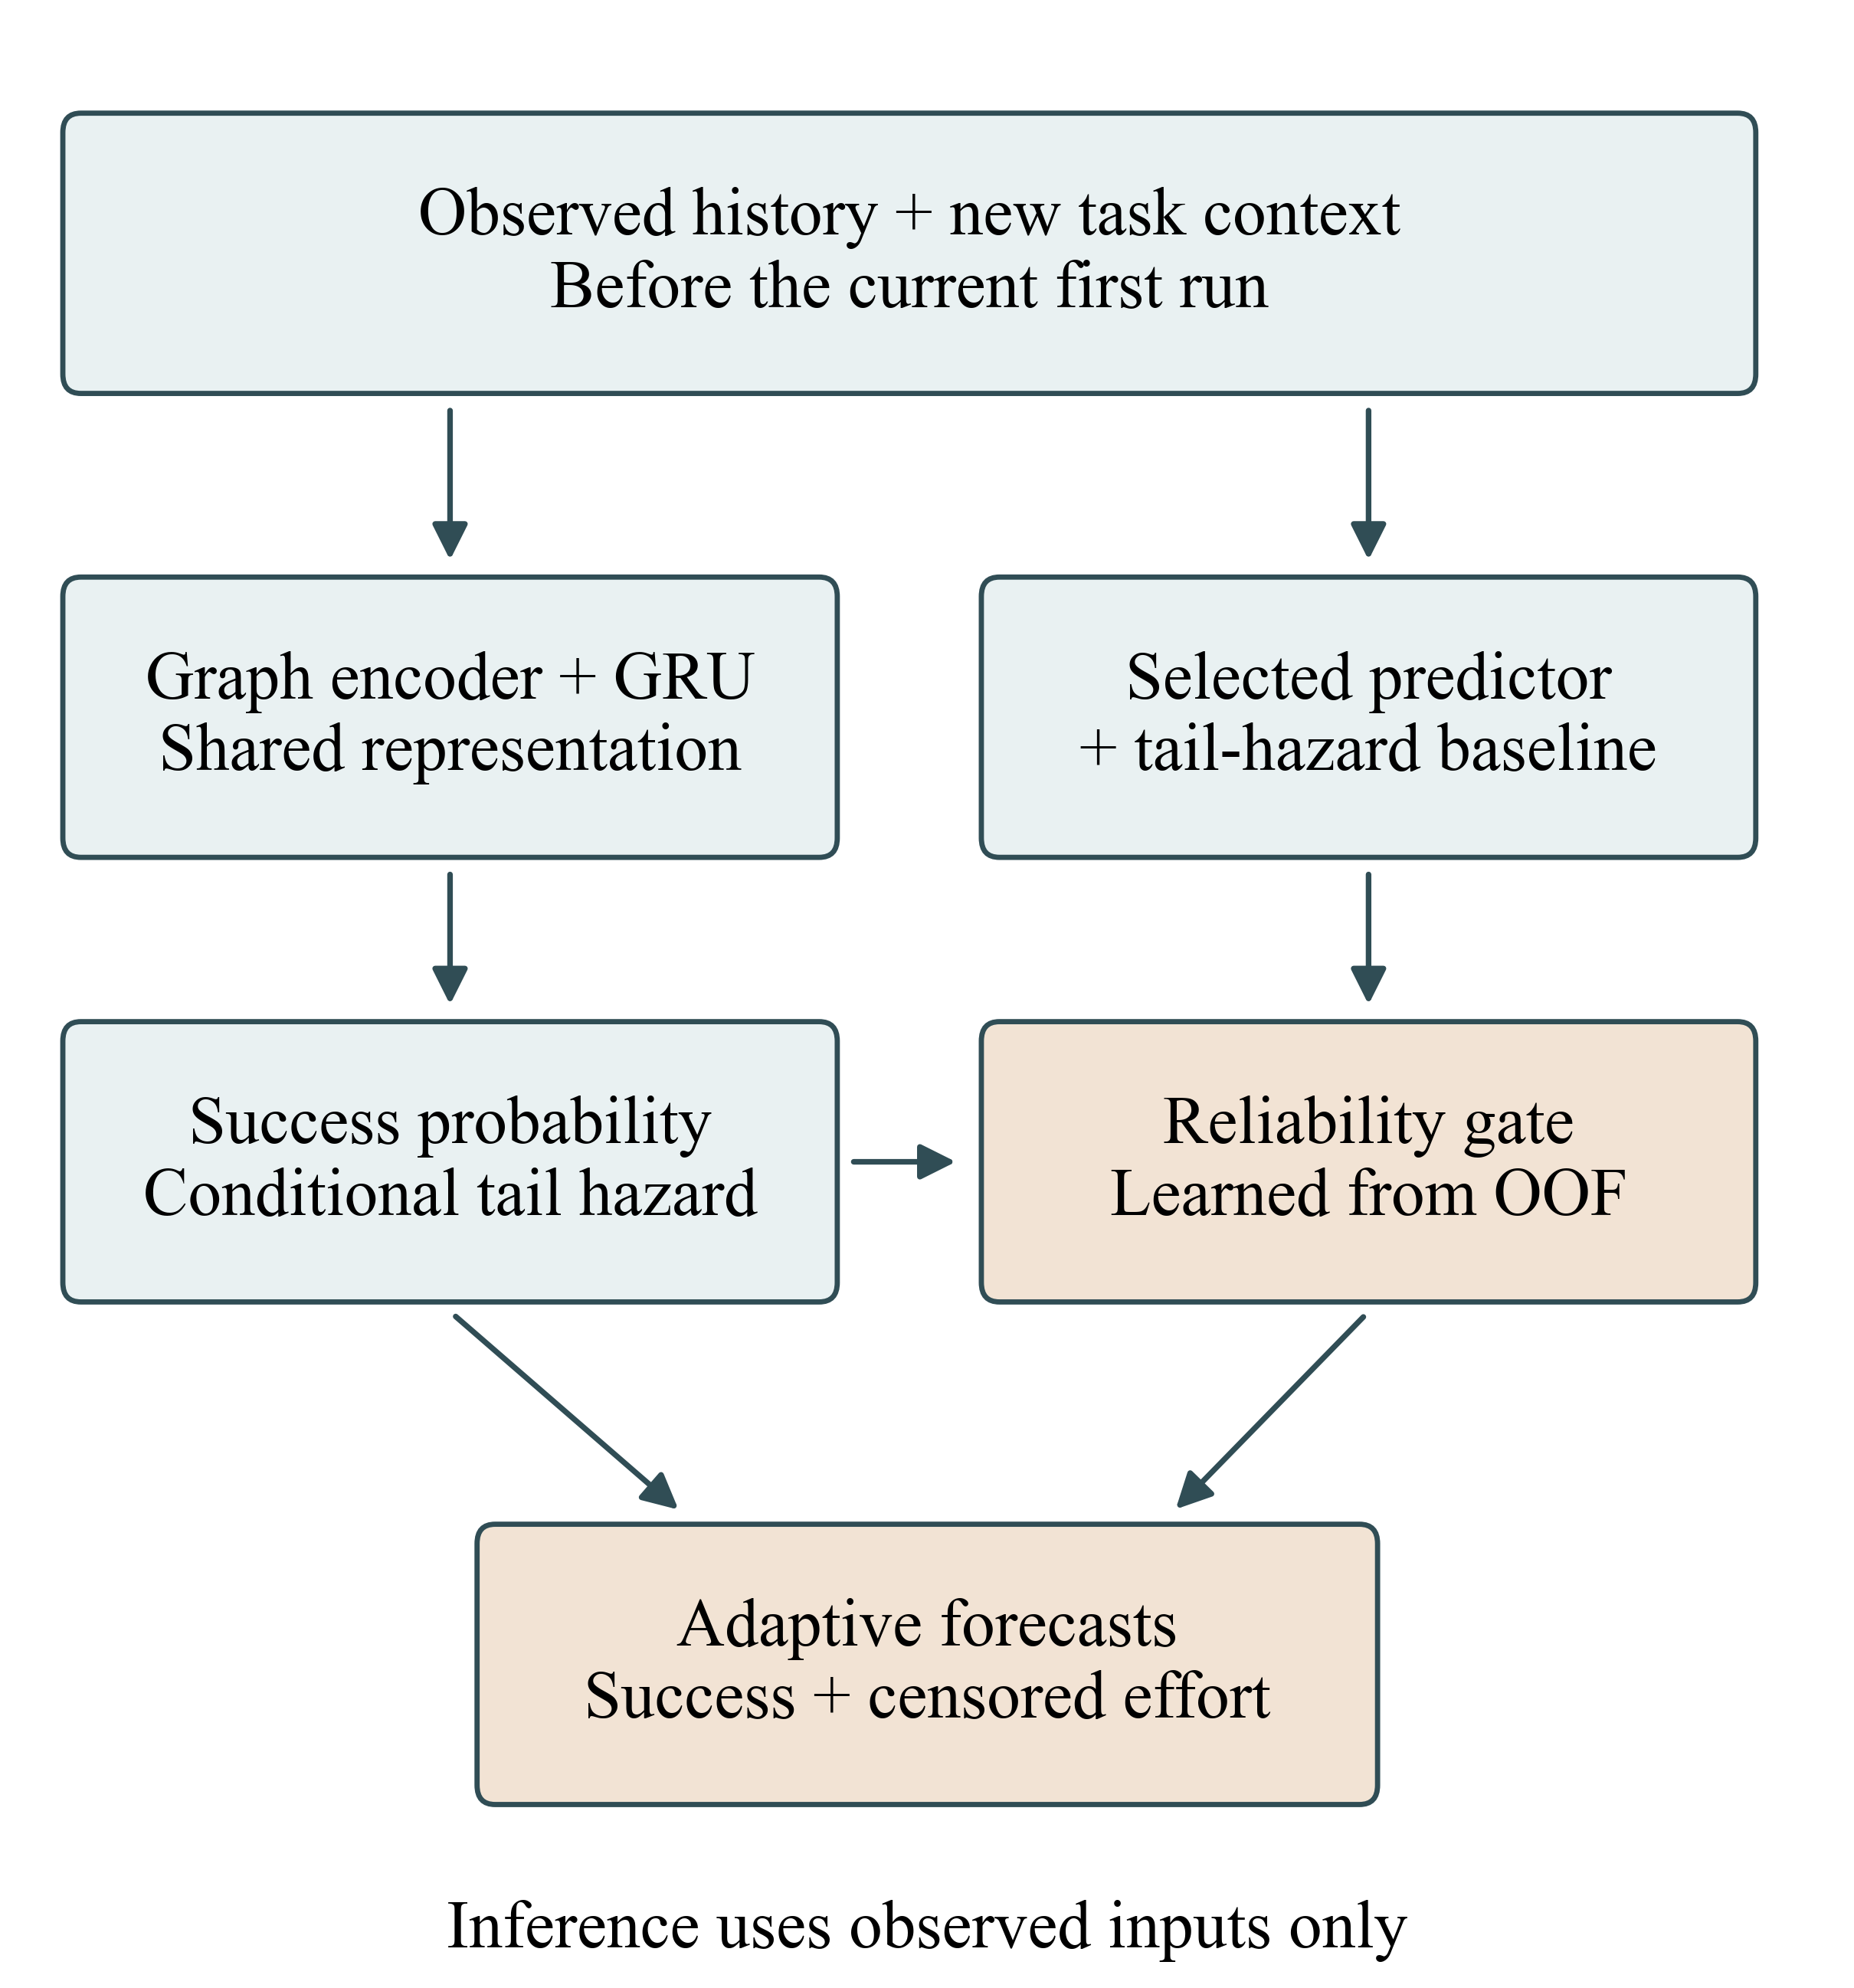

In [15]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(6.8, 7.3), layout="constrained")
ax.set(xlim=(0, 10), ylim=(0, 10))
ax.axis("off")
boxes = {
    "inputs": (
        0.3,
        8.2,
        9.2,
        1.25,
        "Observed history + new task context\nBefore the current first run",
    ),
    "graph": (
        0.3,
        5.8,
        4.1,
        1.25,
        "Graph encoder + GRU\nShared representation",
    ),
    "base": (
        5.4,
        5.8,
        4.1,
        1.25,
        "Selected predictor\n+ tail-hazard baseline",
    ),
    "expert": (
        0.3,
        3.5,
        4.1,
        1.25,
        "Success probability\nConditional tail hazard",
    ),
    "gate": (5.4, 3.5, 4.1, 1.25, "Reliability gate\nLearned from OOF"),
    "result": (
        2.6,
        0.9,
        4.8,
        1.25,
        "Adaptive forecasts\nSuccess + censored effort",
    ),
}
for key, (x, y, width, height, label) in boxes.items():
    color = "#E9F1F2" if key not in ["gate", "result"] else "#F2E3D4"
    ax.add_patch(
        FancyBboxPatch(
            (x, y),
            width,
            height,
            boxstyle="round,pad=0.10",
            facecolor=color,
            edgecolor="#304D55",
            linewidth=1.4,
        )
    )
    ax.text(
        x + width / 2,
        y + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=18,
    )
for start, end in [
    ((2.35, 8.05), (2.35, 7.2)),
    ((7.45, 8.05), (7.45, 7.2)),
    ((2.35, 5.65), (2.35, 4.9)),
    ((7.45, 5.65), (7.45, 4.9)),
    ((4.55, 4.125), (5.2, 4.125)),
    ((7.45, 3.35), (6.35, 2.3)),
    ((2.35, 3.35), (3.65, 2.3)),
]:
    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=20,
            color="#304D55",
            linewidth=1.5,
        )
    )
ax.text(
    5,
    0.15,
    "Inference uses observed inputs only",
    ha="center",
    va="center",
    fontsize=18,
)
save_figure(fig, "07_architecture")
plt.show()


## Вторичная цель: интервалы эффекта

Интервалы относятся к среднему различию NLL наблюдённых записей и получены bootstrap целых учащихся. Это отдельные 95% интервалы для вторичного анализа, а не подтверждение превосходства по основной метрике или одновременное покрытие всех сравнений.

In [16]:
table(
    analysis["effort_effects"],
    "Вторичная цель: NLL comparator − NLL AlphaProg-AGMT; 95% CI",
    "07_effort_effects",
)


Вторичная цель: NLL comparator − NLL AlphaProg-AGMT; 95% CI

,Model,Comparator,Split,n,Effect_NLL,CI_low,CI_high
0,AlphaProg-AGMT,LightGBM,Locked test,22899,0.01027,0.00858,0.01213
1,AlphaProg-AGMT,TabM,Locked test,22899,0.01093,0.00903,0.01284


## Научные ограничения

Данные ретроспективны. RoboMission проверяет перенос на новых учащихся при известных заданиях в общем календарном периоде, а не перенос на неизвестные задания или будущий период. Возраст отдельных пользователей неизвестен; результаты нельзя автоматически приписывать поколению Alpha. Первые посещения без наблюдаемого запуска не имеют бинарной метки и не оценены как известные неудачи.

Toolbox-комбинации обозначают свойства заданий и не являются независимой диагностикой компетенций. Школьные данные не дают индивидуальных соответствий с RoboMission. Педагогическая эффективность рекомендаций, рост учебных результатов и причинный эффект адаптации не проверялись вмешательством.

Сравнение охватывает конкретные воспроизводимые методы и ограниченный бюджет. CUDA-зависимый FA-KT не обучался, поэтому превосходство над всеми современными SOTA-методами не подтверждается. Поиск выполнялся на OOF и validation; закрытый тест использован после фиксации конфигурации.

Геометрическая модель трудоёмкости предполагает постоянный условный hazard; IPCW зависит от допущения о цензурировании. Кластерный bootstrap не устраняет зависимость внутри неизвестных классов. У школьной ветви только две независимые тестовые школы. Измерения времени относятся к текущему устройству; пиковая память не измерена. Внутренние веса объясняют смешивание экспертов, но не причинные механизмы обучения.

Вероятности относятся к наблюдённому выбору задания. Улучшение прогнозной метрики не доказывает пользу рекомендательной политики или рост навыков после педагогического вмешательства.

In [17]:
assert all(
    len(analysis[name]) > 0
    for name in [
        "primary",
        "ranking",
        "calibration",
        "statistics",
        "seeds",
        "efficiency",
    ]
)
assert json.loads(
    (ROOT / "dataset/protocol/robomission_protocol.json").read_text()
)["locked_test_opened"]
